In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import requests
import json
from matplotlib.pyplot import text

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


matplotlib.rcParams['font.size'] = 18
# matplotlib.rcParams['font.size'] = 16ho

import re
import time
import subprocess
import os
import signal


# Patch and benchmark control

In [3]:
backend_endpoint ="127.0.0.1:5000"

In [4]:


def reset_shares_cfs(backend=backend_endpoint):
    params = { 'script': 'setup_patch_clean_cfs.sh', "ema":"1000" }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text)    

def reset_shares_llf(backend=backend_endpoint, ema=1000):
    params = { 'script': 'setup_patch_clean_systemd.sh', "ema":ema }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text)       
    
def reset_shares_llf_static(backend=backend_endpoint):
    params = { 'script': 'setup_patch_clean_withrr_systemd.sh', "ema":1000 }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text)        
    
def rd_hashd_benchmark_start(backend=backend_endpoint, func_count=0,duration=100,llf=False, ema=1000,ftrace_enabled=False):
    params = { "funcs_count": func_count, "duration":duration, "llf": llf, "ema":ema  }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_start", params=params, headers={})
    print(r.text)  
    
def rd_hashd_benchmark_reports(backend=backend_endpoint):
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_reports", params={}, headers={})
    return r.text      

def rd_hashd_benchmark_killall(backend=backend_endpoint):
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_killall", params={}, headers={})
    return r.text     

def rd_hashd_benchmark_latencies_all_funcs(backend=backend_endpoint):
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_latencies_all_funcs", params={}, headers={})
    return r.text   
    
def rd_hashd_benchmark_end(backend=backend_endpoint, func_count=0,duration=100):
    params = { "funcs_count": func_count, "duration":duration }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_end", params=params, headers={})
    print(r.text)       

In [5]:
def rd_hashd_benchmark_end(backend=backend_endpoint, func_count=0,duration=100):
    params = { "funcs_count": func_count, "duration":duration }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_end", params=params, headers={})
    print(r.text)       

In [6]:
    
def rd_hashd_benchmark_hetro_start(backend=backend_endpoint, func_count=0,func_sm_count=0):
    params = { "funcs_count": func_count, "funcs_sm_count": func_sm_count, }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_hetro_start", params=params, headers={})
    print(r.text)  
    
def rd_hashd_benchmark_hetro_end(backend=backend_endpoint, func_count=0,func_sm_count=0):
    params = { "funcs_count": func_count, "funcs_sm_count": func_sm_count, }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_hetro_end", params=params, headers={})
    print(r.text)   

In [7]:
reset_shares_cfs()
# reset_shares_llf_static()

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----



# Kernel metrics

In [6]:

def cat_trace_stat(backend="192.168.14.2:5000"):
    params = { 'script': 'cat_trace_stat.sh', "ema":"1000" }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text) 
    
    return r.text
    
    
def function_profile_enabled(backend="192.168.14.2:5000",enabled=1):
    params = { "enabled":enabled }
    r = requests.get(f"http://{backend}/function_profile_enabled", params=params, headers={})
    print(r.text) 
    
    
def process_ftrace_data(ftrace_data):
    
#     print(ftrace_data.split("\n")[0].split())
#     print([x for x in range(4)])
    
    raw_schedule_lines = [line.split() for line in ftrace_data.split("\n") if re.findall("schedule",line)]
    assert(len(raw_schedule_lines) == 12)
    
    print(raw_schedule_lines)
    
    # ['schedule', '8267', '912739427', 'us', '110407.5', 'us', '224351.8', 'us']    

    schedule_hits_total = [int(line[1]) for line in raw_schedule_lines]
    schedule_time_total = [int(line[2]) for line in raw_schedule_lines]
    schedule_time_avg = [float(line[4]) for line in raw_schedule_lines]
    schedule_time_std = [float(line[6]) for line in raw_schedule_lines]
    
    schedule_time_avg_avg = sum(schedule_time_avg)/len(schedule_time_avg)
    
    return sum(schedule_hits_total), sum(schedule_time_total), schedule_time_avg_avg, max(schedule_time_std) 

In [7]:


# function_profile_enabled(enabled=0)
function_profile_enabled()
ftrace_data_raw = cat_trace_stat()
# ftrace_data = process_ftrace_data(ftrace_data_raw)
# display(ftrace_data_raw)

time.sleep(10)

ftrace_data_raw = cat_trace_stat()



Reseting ftrace state...

current_tracer, before:
     1	nop
current_tracer, after:
     1	nop

set_ftrace_filter, before:
     1	#### all functions enabled ####
set_ftrace_filter, after:
     1	#### all functions enabled ####

set_graph_function, before:
     1	#### all functions enabled ####
set_graph_function, after:
     1	#### all functions enabled ####

set_ftrace_pid, before:
     1	no pid
set_ftrace_pid, after:
     1	no pid

events/enable, before:
     1	0
events/enable, after:
     1	0

tracing_thresh, before:
     1	0
tracing_thresh, after:
     1	0

kprobe_events, before:
kprobe_events, after:

tracing_on, before:
     1	1
tracing_on, after:
     1	1

Done.
/sys/kernel/debug/tracing/function_profile_enabled
0
configurating ftrace to instrument schedule()
/sys/kernel/tracing/set_ftrace_filter
schedule
/sys/kernel/tracing/current_tracer
function
/sys/kernel/tracing/tracing_on
0
/sys/kernel/debug/tracing/function_profile_enabled
1

  Function                               Hit 

In [8]:
function_profile_enabled()

ftrace_data_raw = cat_trace_stat()


Reseting ftrace state...

current_tracer, before:
     1	function
current_tracer, after:
     1	nop

set_ftrace_filter, before:
     1	schedule
set_ftrace_filter, after:
     1	#### all functions enabled ####

set_graph_function, before:
     1	#### all functions enabled ####
set_graph_function, after:
     1	#### all functions enabled ####

set_ftrace_pid, before:
     1	no pid
set_ftrace_pid, after:
     1	no pid

events/enable, before:
     1	0
events/enable, after:
     1	0

tracing_thresh, before:
     1	0
tracing_thresh, after:
     1	0

kprobe_events, before:
kprobe_events, after:

tracing_on, before:
     1	0
tracing_on, after:
     1	1

Done.
/sys/kernel/debug/tracing/function_profile_enabled
0
configurating ftrace to instrument schedule()
/sys/kernel/tracing/set_ftrace_filter
schedule
/sys/kernel/tracing/current_tracer
function
/sys/kernel/tracing/tracing_on
0
/sys/kernel/debug/tracing/function_profile_enabled
1

  Function                               Hit    Time           

In [7]:
# domain<N> <name> <cpumask> 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45

def schedstat_domains_snapshot():
    
    df = pd.DataFrame()
    
    backend=backend_endpoint
    r = requests.get(f"http://{backend}/schedstat_domains", params={}, headers={})
    schedstat_data = r.text    

    cpu = 0
    for line in schedstat_data.split('\n'):
        if len(line) > 0: 
#             print(line)
            cpu_entry = line.split(" ")
#             print([(a,b) for a,b in enumerate(cpu_entry)][:2])
#             print(cpu_entry[2:])
        
#             print([(a,b) for a,b in enumerate(cpu_entry)][2:])
#             print(cpu_entry[1],cpu_entry[4+1], cpu_entry[12+1], cpu_entry[20+1])
            entry = {
#                 "id": cpu_entry[1],
                "imbalances": int(cpu_entry[4+1]) + int(cpu_entry[12+1]) + int(cpu_entry[20+1]),
                
                "imbalance_idle":int(cpu_entry[4+1]),
                "pull_task_idle": int(cpu_entry[5+1]),
#                 "pull_task_idle_hotcache": int(cpu_entry[5+2]),
                
                "imbalance_busy": int(cpu_entry[12+1]),
                "pull_task_busy": int(cpu_entry[13+1]),
#                 "pull_task_busy_hotcache": int(cpu_entry[13+2]),
                
                "imbalance_newly_idle": int(cpu_entry[20+1]),
                "pull_task_newly_idle": int(cpu_entry[21+1]),
#                 "pull_task_newly_idle_hotcache": int(cpu_entry[21+1]),
                "active_load_balance": cpu_entry[27+1],
                "passive_load_balance": cpu_entry[36+1],
#                 "try_to_wake_up": cpu_entry[5],
#                 "try_to_wake_up local": cpu_entry[6],
#                 "tasks_running": cpu_entry[7],
#                 "tasks_waiting": cpu_entry[8],
#                 "timeslices": cpu_entry[9]
            }
            
            df[cpu] = cpu_entry[2:]
            cpu = cpu+1
                
#             for entry in range(1,9+1):
#                 value = cpu_entry[entry] # 3 of times schedule() was called
#     #             print("schedule()", value) 
#                 df[entry] = df[entry] + int(value)
            
    return df
    
a = schedstat_domains_snapshot()
time.sleep(10)
b = schedstat_domains_snapshot()

(b.astype(int) - a.astype(int)).sum(axis=1)
# b

/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

0     1445
1     1445
2        0
3        0
4        0
5        0
6        0
7     1445
8       11
9       11
10       0
11       0
12       0
13       0
14       0
15      11
16      95
17      95
18       0
19       0
20       0
21       0
22       0
23      95
24       0
25       0
26       0
27       0
28       0
29       0
30       0
31       0
32       0
33      14
34      13
35       0
dtype: int64

In [8]:

def nr_switches_snapshot():
    df = pd.DataFrame()

    r = requests.get(f"http://{backend_endpoint}/nr_switches", params={}, headers={})
    nr_switches_data = r.text    
    
    data = []
    for line in nr_switches_data.split("\n"):
        if len(line) > 0: 
            data.append(int(line.split(":")[1]))
            
            
    df['nr_switches'] = data
            
            
    return df

In [9]:
# First field is a sched_yield() statistic:

# 0 of times sched_yield() was called

# Next three are schedule() statistics:

# 1 This field is a legacy array expiration count field used in the O(1) scheduler. We kept it for ABI compatibility, but it is always set to zero.

# 2 # of times schedule() was called

# 3 # of times schedule() left the processor idle

# Next two are try_to_wake_up() statistics:

# # 4 of times try_to_wake_up() was called

# # 5 of times try_to_wake_up() was called to wake up the local cpu

# Next three are statistics describing scheduling latency:

# 6 sum of all time spent running by tasks on this processor (in nanoseconds)

# 7 sum of all time spent waiting to run by tasks on this processor (in nanoseconds)

# 8 # of timeslices run on this cpu

def schedstat_snapshot():
    
    df = pd.DataFrame()
    
    r = requests.get(f"http://{backend_endpoint}/schedstat", params={}, headers={})
    schedstat_data = r.text    

    for line in schedstat_data.split('\n'):
        if len(line) > 0: 
            cpu_entry = line.split(" ")
#             print(len(cpu_entry), cpu_entry)
            entry = {
                "yield": cpu_entry[1],
                "schedule": cpu_entry[3],
                "idle": cpu_entry[4],
                "try_to_wake_up": cpu_entry[5],
                "try_to_wake_up local": cpu_entry[6],
                "tasks_running": cpu_entry[7],
                "tasks_waiting": cpu_entry[8],
                "timeslices": cpu_entry[9]
            }
            
            # df = df.append(entry,ignore_index=True)
            new_row_df = pd.DataFrame([entry])
            df = pd.concat([df, new_row_df], ignore_index=True)
            
            
                
#             for entry in range(1,9+1):
#                 value = cpu_entry[entry] # 3 of times schedule() was called
#     #             print("schedule()", value) 
#                 df[entry] = df[entry] + int(value)
            
    return df
    
a = schedstat_snapshot()
b = schedstat_snapshot()

display((b.astype(int) - a.astype(int)).sum())

nr_switches_start = nr_switches_snapshot()

# time.sleep(10)
nr_switches_end = nr_switches_snapshot()

display((nr_switches_end - nr_switches_start).sum())


yield                          0
schedule                      85
idle                          42
try_to_wake_up                39
try_to_wake_up local          10
tasks_running           58072063
tasks_waiting              24346
timeslices                    43
dtype: int64

nr_switches    246
dtype: int64

In [148]:
def call_with_retry():
    while True:
        try:
            result = schedstat_snapshot()  # Attempt to call the function
            print(f"Function succeeded: ", result)
            break  # Exit the loop if the function succeeds
        except Exception as e:
            print(f"Error occurred: {e}. Retrying...")
            time.sleep(10)  # Sleep for a short time before retrying
            
def reboot_and_wait_until_online():
    backend="192.168.14.2:5000"
    try:
        r = requests.get(f"http://{backend}/reboot", params={}, headers={})
        print(r.text) 
    except Exception as e:
        print(f"Error occurred: {e}. Waiting...")
        call_with_retry()    
    

In [145]:
call_with_retry()

Function succeeded:     idle schedule tasks_running tasks_waiting timeslices try_to_wake_up  \
0     0        0    5222439893    2119200224      10876              0   
1     0        0    2948242348     522228855       9542              0   
2     0        0    3176124302     739769982      14485              0   
3     0        0    3095665556    1203167784      18762              0   
4     0        0    2937362317    2358498107      11912              0   
5     0        0    3357264499    1395910121      12645              0   
6     0        0    2636474510    1048276583      14995              0   
7     0        0    2705863934     699065353      16284              0   
8     0        0    2252948489     313414894      13044              0   
9     0        0    2970764323    1030773694      11765              0   
10    0        0    2467422982    1268657416      12070              0   
11    0        0    2774697060     482313124      13705              0   

   try_to_wake_u

# Benchmark data processing

In [10]:
# def process_snapshot(json_files):
    
# #     print(json_files)
    
#     concurrency_per_func = [json.loads(file)['concurrency'] for file in json_files]
#     rps_per_func = [json.loads(file)['rps'] for file in json_files]
    
#     nr_workers_per_func = [json.loads(file)['nr_workers'] for file in json_files]
#     nr_idle_workers_per_func = [json.loads(file)['nr_idle_workers'] for file in json_files]
#     nr_in_flight_per_func = [json.loads(file)['nr_in_flight'] for file in json_files]
    
#     nr_done_per_func = [json.loads(file)['nr_done'] for file in json_files]
#     lat_p95_per_func = [json.loads(file)['lat']['p95'] for file in json_files]
#     lat_p50_per_func = [json.loads(file)['lat']['p50'] for file in json_files]


#     print('concurrency_per_func', concurrency_per_func, sum(concurrency_per_func))
#     print('rps_per_func', rps_per_func, sum(rps_per_func))
    
#     print('nr_workers_per_func', nr_workers_per_func, sum(nr_workers_per_func))
#     print('nr_idle_workers_per_func', nr_idle_workers_per_func,sum(nr_idle_workers_per_func))
#     print('nr_in_flight_per_func', nr_in_flight_per_func, sum(nr_in_flight_per_func))    
    
#     print('nr_done_per_func', nr_done_per_func, sum(nr_done_per_func))
    
#     print('lat_p95_per_func', lat_p95_per_func, max(lat_p95_per_func))        
#     print('lat_p50_per_func', lat_p50_per_func, max(lat_p50_per_func))     
    
#     return [sum(concurrency_per_func),sum(rps_per_func),
#             sum(nr_done_per_func),
#             max(lat_p95_per_func),
#             max(lat_p50_per_func)]

# def hashd_report_snapshot():
    
#     try:
#         single = rd_hashd_benchmark_reports()
#         json.loads(single)
        
#         json_files = [single]
#         print("single json file")
#     except:
  
#         raw_data = [row for row in rd_hashd_benchmark_reports().split("==> /local/scratch/rd-hashd/")[1:]]

#         json_filenames = [row.split(" <==")[0] for row in raw_data ]
#         json_files = [row.split(" <==")[1] for row in raw_data ]

#         print("fetched the following JSON files", len(json_filenames),json_filenames)
#     # print("with the following keys",  json.loads(json_files[0]).keys())
    
#     process_snapshot(json_files)
    
#     return json_files



In [11]:
hashd_report_snapshot()

NameError: name 'hashd_report_snapshot' is not defined

In [12]:
# latencies_raw = rd_hashd_benchmark_latencies_all_funcs()

def process_latencies(latencies_raw):
    
    logs_per_func = [s for s in latencies_raw.split("\n") if re.match('logs-\d+|logs-sm-\d+',s)]
    latencies_per_func_raw = re.split(r'logs-\d+|logs-sm-\d+', latencies_raw)[1:]

    # the number of log file names should be equal to the actual number of files
    assert (len(logs_per_func) == len(latencies_per_func_raw))
    
    if (len(logs_per_func) == 0):
        logs_per_func = [s for s in [latencies_raw.split("\n")]]
        latencies_per_func_raw = [latencies_raw]  
    

    per_func_latencies_raw = [group.split("\n")[1:-1] for group in latencies_per_func_raw]
    
    
    def extract_latencies(group):
        return [float(r.strip("ms")) for r in group]

    data = [extract_latencies(group) for group in per_func_latencies_raw]
        
    if (len(logs_per_func) == 1):
        df = pd.DataFrame(data[0],columns=["logs-0"])
        df.hist(cumulative=True, density=1, bins=1000,histtype='step',figsize=(3,2))
        plt.show()
        
    else:

        df = pd.DataFrame(data).transpose()

        df.columns = logs_per_func
#         axs = df.hist(cumulative=True, density=1, bins=1000,histtype='step',figsize=(15,10))

#         plt.tight_layout()
#         for row in axs:
#             for ax in row:
#                 ax.set_xlim(0,1500)

#         plt.show()
#         pd.Series(df.to_numpy().flatten()).hist(cumulative=True, density=0, bins=1000,histtype='step',figsize=(4,2))
#         plt.show()
    return df

# process_latencies(latencies_raw)

# Preparing files

In [13]:


def rd_hashd_benchmark_args_workload(backend=backend_endpoint,workload='none',functions=400):
    params = { 'workload': workload, "functions":functions }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_args_workload", params=params, headers={})
    print(r.text.split('\n')[-10:])   
    
rd_hashd_benchmark_args_workload(workload='none',functions=360)    

['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-994",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-995",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-996",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-997",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-998",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-999",', '']


# Parameter space

In [14]:
!cat ~/CFS-LLF_main/rd-hashd/params.json | grep '\/\/'

# //
# // rd-hashd runtime parameters
# //
# // All parameters can be updated while running and will be applied immediately.
# //
# // rd-hashd keeps calculating SHA1s of different parts of testfiles using
# // concurrent worker threads. The testfile indices and hash sizes are
# // determined using truncated normal distributions which gradually transforms
# // to uniform distributions as their standard deviations increase.
# //
# // All durations are in seconds and memory bytes. A _frac field should be <=
# // 1.0 and specifies a sub-proportion of some other value. A _ratio field is
# // similar but may be greater than 1.0.
# //
# // The concurrency level is modulated using two PID controllers to target the
# // specified latency and RPS so that neither is exceeded. The total number
# // of concurrent threads is limited by `concurrency_max`.
# //
# // The total size of testfiles is set up during startup and can't be changed
# // online. However, the portion which is actively used by rd

## Parameter space - independent values

In [15]:
!cat ~/CFS-LLF_main/rd-hashd/params.json  | grep -v '\/\/\|lat_target\|sleep\|concurrency'

{
  "control_period": 1.0,
  "rps_target": 65536,
  "rps_max": 1000,
  "mem_frac": 0.001,
  "chunk_pages": 25,
  "file_frac": 0.25,
  "file_size_mean": 377487,
  "file_size_stdev_ratio": 0.45,
  "file_addr_stdev_ratio": 0.215,
  "file_addr_rps_base_frac": 0.5,
  "file_write_frac": 0.0,
  "anon_size_ratio": 2.3,
  "anon_size_stdev_ratio": 0.45,
  "anon_addr_stdev_ratio": 0.235,
  "anon_addr_rps_base_frac": 0.5,
  "anon_write_frac": 0.3,
  "cpu_ratio": 0.93,
  "log_bps": 1100794,
  "fake_cpu_load": false,
  "acc_dist_slots": 0,
  "lat_pid": {
    "kp": 0.1,
    "ki": 0.01,
    "kd": 0.01
  },
  "rps_pid": {
    "kp": 0.25,
    "ki": 0.01,
    "kd": 0.01
  }
}


## Parameter space - tuned values

In [16]:
!cat ~/CFS-LLF_main/rd-hashd/params.json  | grep 'lat_target\|sleep\|concurrency'

# // The concurrency level is modulated using two PID controllers to target the
# // of concurrent threads is limited by `concurrency_max`.
# // Worker threads will sleep according to the sleep duration distribution and
# //  concurrency_max: Maximum number of worker threads
# //  lat_target_pct: Latency target percentile
# //  lat_target: Latency target
# //  sleep_mean: Worker sleep duration average
# //  sleep_stdev_ratio: Standard deviation of sleep duration distribution
  "concurrency_max": 65536,
  "lat_target_pct": 0.5,
  "lat_target": 0.1,
  "sleep_mean": 0.02,
  "sleep_stdev_ratio": 0.33,


# Visualisation code

In [689]:
import pickle


In [693]:
file_notraceftrace_cfs = open('/local/scratch/sosp25/results_notraceftrace_cfs', 'wb')
pickle.dump(results_notraceftrace_cfs, file_notraceftrace_cfs)

In [690]:

file_azure2021ftrace_cfs = open('/local/scratch/sosp25/results_azure2021ftrace_cfs', 'wb')
pickle.dump(results_azure2021ftrace_cfs, file_azure2021ftrace_cfs)

file_azure2021ftrace_llf = open('/local/scratch/sosp25/results_azure2021ftrace_llf', 'wb')
pickle.dump(results_azure2021ftrace_llf, file_azure2021ftrace_llf)   

In [691]:
file_notraceclean_cfs = open('/local/scratch/sosp25/results_notraceclean_cfs', 'wb')
pickle.dump(results_notraceclean_cfs, file_notraceclean_cfs)

file_notraceclean_llf = open('/local/scratch/sosp25/results_notraceclean_llf', 'wb')
pickle.dump(results_notraceclean_llf, file_notraceclean_llf)

In [692]:
file_azure2021clean_cfs = open('/local/scratch/sosp25/results_azure2021clean_cfs', 'wb')
pickle.dump(results_azure2021clean_cfs, file_azure2021clean_cfs)

file_azure2021clean_llf = open('/local/scratch/sosp25/results_azure2021clean_llf', 'wb')
pickle.dump(results_azure2021clean_llf, file_azure2021clean_llf)

In [694]:
file_randomclean_cfs = open('/local/scratch/sosp25/results_randomclean_cfs', 'wb')
pickle.dump(results_randomclean_cfs, file_randomclean_cfs)

file_randomclean_llf = open('/local/scratch/sosp25/results_randomclean_llf', 'wb')
pickle.dump(results_randomclean_llf, file_randomclean_llf)

In [ ]:
results_notraceclean_cfs
results_notraceclean_llf
results_azure2021clean_cfs
results_azure2021clean_llf
results_randomclean_cfs
results_randomclean_llf

In [277]:
!mkdir /local/scratch/sosp25/figures

In [312]:
!ls /local/scratch/sosp25/figures/problem*

/local/scratch/sosp25/figures/problem-schedule-avg.pdf
/local/scratch/sosp25/figures/problem-schedule-time.pdf
/local/scratch/sosp25/figures/problem-throughput.pdf


In [401]:
!ls /local/scratch/sosp25/figures/solution*

/local/scratch/sosp25/figures/solution-azure2021-latency-median.pdf
/local/scratch/sosp25/figures/solution-azure2021-latency-tail.pdf
/local/scratch/sosp25/figures/solution-azure2021-schedule-avg.pdf
/local/scratch/sosp25/figures/solution-azure2021-schedule-time.pdf
/local/scratch/sosp25/figures/solution-azure2021-throughput.pdf
/local/scratch/sosp25/figures/solution-cdf-132funcs.pdf
/local/scratch/sosp25/figures/solution-cdf-228funcs.pdf
/local/scratch/sosp25/figures/solution-cdf-36funcs.pdf


# Experiment code

In [17]:

def enable_schedstats(backend=backend_endpoint,enabled=1):
    params = { "enabled":enabled }
    r = requests.get(f"http://{backend}/enable_schedstats", params=params, headers={})
    print(r.text) 
    
enable_schedstats()    

kernel.sched_schedstats = 1



In [18]:
def rd_hashd_experiment(func_count = 20,
                        llf=False, 
                        llf_static=False,
                        ema=1000,
                        duration=150,
                        workload='none',
                        schedstats_enabled=False, 
                        ftrace_enabled=False):

    #machine reset
    reset_shares_cfs()
    a = int(func_count)
    print(a, "functions")
    
    rd_hashd_benchmark_args_workload(workload=workload,functions=360)  
    
    #benchmark kickoff
    rd_hashd_benchmark_start(func_count=(a-1),llf=llf,ema=ema, ftrace_enabled=ftrace_enabled)
#     if (llf): reset_shares_llf(ema=ema)
#     if (llf_static): reset_shares_llf_static()
        
    #instrumentation begins here
    ts_start = time.time()    
    if ftrace_enabled:
#         function_profile_enabled(enabled=0)    
        function_profile_enabled(enabled=1)
        cat_trace_stat()
    if schedstats_enabled:
        enable_schedstats(enabled=1)
    schedstat_start = schedstat_snapshot()
    schedstat_domains_start = schedstat_domains_snapshot()
    nr_switches_start = nr_switches_snapshot()

    #experiment timer        
    interval=10
    snapshots = []
    for i in range(0,duration,interval):
        print("tick",i)
#         snapshots.append(hashd_report_snapshot())
        time.sleep(interval)
    snapshots_hetro = snapshots

    #instrumentation end    
    ts_end = time.time()    
    schedstat_end = schedstat_snapshot()
    schedstat_domains_end = schedstat_domains_snapshot()
    nr_switches_end = nr_switches_snapshot()
    if ftrace_enabled:
        ftrace_data_raw = cat_trace_stat()
    
    #benchmark killed
    rd_hashd_benchmark_killall()
    rd_hashd_benchmark_end(func_count=(a-1))
    
    #machine reset
    reset_shares_cfs()    
    
    #display results
    print('duration', ts_end-ts_start, 'seconds')
    schedstat_hetro = (schedstat_end.astype(int) - schedstat_start.astype(int)).sum()
    # scheddomain_hetro = (schedstat_domains_end.astype(int) - schedstat_domains_start.astype(int)).sum(axis=1)
    scheddomain_hetro = None
    display((nr_switches_end - nr_switches_start).sum())

    display(schedstat_hetro)
    # display(scheddomain_hetro) 
    if ftrace_enabled:
        ftrace_data = process_ftrace_data(ftrace_data_raw)
    else: ftrace_data = None

    latencies_raw = rd_hashd_benchmark_latencies_all_funcs()
    df = process_latencies(latencies_raw)

    return (df,
        schedstat_hetro,
        scheddomain_hetro, 
        ftrace_data,
        ts_end-ts_start)



# Results (no special kernel metrics)

In [24]:
density_range = [x for x in range(12, 12*20, 12*4)]
density_range = [12]
# density_range = [204]
results_notraceclean_cfs = {}

results_notraceclean_llf = {}


In [25]:
density_range = [204]


In [22]:
!git status
!git diff ../scripts
!git diff ../rd-hashd

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
  (commit or discard the untracked or modified content in submodules)
	modified:   ../linux (new commits, untracked content)
	modified:   rd-hashd (fibo) experiments (compact).ipynb
	modified:   ../rd-hashd/func@.service
	modified:   ../scripts/setup_patch_clean_cfs.sh
	modified:   ../scripts/setup_patch_clean_systemd.sh

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../rd-hashd/results/testfiles/
	../scripts/.setup_patch_clean_cfs.sh.swp

no changes added to commit (use "git add" and/or "git commit -a")
diff --git a/scripts/setup_patch_clean_cfs.sh b/scripts/setup_patch_clean_cfs.sh
index a31c532..b2de0a5 100755
--- a/scripts/setup_patch_clean_cfs.sh
+++ b/scripts/setup_pa

In [26]:

print(density_range)

for x in density_range: 
    results_notraceclean_cfs[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


print(density_range)

for x in density_range: 
    results_notraceclean_llf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)                                                   

[204]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

204 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-99

/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

tick 0
tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 15:29:39 helios.cl.cam.ac.uk rd-hashd[4306]: [INFO] p50: 96.7 p84:137.3 p90:148.4 p99:193.8 rps:  24.1 con:  3.8
Jul 22 15:29:49 helios.cl.cam.ac.uk rd-hashd[4306]: [INFO] p50: 91.3 p84:124.2 p90:131.5 p99:169.1 rps:  24.2 con:  4.1
Jul 22 15:29:59 helios.cl.cam.ac.uk rd-hashd[4306]: [INFO] p50:106.7 p84:144.0 p90:154.4 p99:194.6 rps:  26.7 con:  4.1
Jul 22 15:30:10 helios.cl.cam.ac.uk rd-hashd[4306]: [INFO] p50:110.0 p84:155.0 p90:166.5 p99:190.6 rps:  25.7 con:  4.0
Jul 22 15:30:20 helios.cl.cam.ac.uk rd-hashd[4306]: [INFO] p50:101.3 p84:135.1 p90:151.1 p99:184.7 rps:  24.0 con:  4.0
Jul 22 15:30:30 helios.cl.cam.ac.uk rd-hashd[4306]: [INFO] p50:104.1 p84:138.4 p90:154.4 p99:183.3 rps:  24.6 con:  3.8
Jul 22 15:30:40 helios.cl.cam.ac.uk rd-hashd[4306]: [INFO] p50: 97.0 p84:133.2 p90:144.3 p99:168.9 rps:  23.8 con:  4.0
Jul

...

tick 0
tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 15:31:33 helios.cl.cam.ac.uk rd-hashd[22016]: [INFO] Starting hasher (maxcon=65536 lat=100.0ms rps=65536 file=0.06G anon=0.19G)
Jul 22 15:31:33 helios.cl.cam.ac.uk rd-hashd[22016]: [INFO] Setting up hash logging at results/logs-0 (31.38G @ 1.05Mbps pad 1.08k)
Jul 22 15:31:33 helios.cl.cam.ac.uk rd-hashd[22016]: No trace provided, executing default code path...
Jul 22 15:31:44 helios.cl.cam.ac.uk rd-hashd[22016]: [INFO] p50:516.0 p84:969.5 p90:1116.0 p99:1607.1 rps:  57.6 con: 10.4
Jul 22 15:31:55 helios.cl.cam.ac.uk rd-hashd[22016]: [INFO] p50:236.4 p84:346.6 p90:359.3 p99:446.9 rps:  22.2 con:  2.8
Jul 22 15:32:06 helios.cl.cam.ac.uk rd-hashd[22016]: [INFO] p50: 80.7 p84:109.6 p90:117.6 p99:142.5 rps:  18.0 con:  2.9
Jul 22 15:33:52 helios.cl.cam.ac.uk systemd[1]: Stopping Function stress 0...
Jul 22 15:33:53 helios.cl.cam.

nr_switches    4907493
dtype: int64

yield                          3199673
schedule                       8976356
idle                               196
try_to_wake_up                 2395551
try_to_wake_up local           1904527
tasks_running           11354586537068
tasks_waiting           88428161235930
timeslices                     4878105
dtype: int64

In [32]:
!git diff ../scripts/setup_patch_clean_systemd.sh

diff --git a/scripts/setup_patch_clean_systemd.sh b/scripts/setup_patch_clean_systemd.sh
index e1aa179..8919e19 100755
--- a/scripts/setup_patch_clean_systemd.sh
+++ b/scripts/setup_patch_clean_systemd.sh
@@ -17,7 +17,7 @@ echo "-----"
 # # echo "#sched_entity_before_policy == 20  entity_before_se_load_avg_most(a,b) //this destroys performance"
 sudo sysctl kernel.sched_entity_before_policy=1
 sudo sysctl kernel.sched_check_preempt_wakeup_latency_awareness=100
-sudo sysctl kernel.sched_cpu_has_higher_load_task=100
+sudo sysctl kernel.sched_cpu_has_higher_load_task=0
 echo "-----"
 
 # sudo sysctl kernel.sched_tg_load_avg_sticky=0
@@ -35,8 +35,8 @@ echo "/sys/fs/cgroup/cpu/*/cpu.shares"
 echo "/sys/fs/cgroup/cpu/*/*/cpu.shares"
 echo "/sys/fs/cgroup/cpu/*/*/*/cpu.shares"
 echo "/sys/fs/cgroup/cpu/*/*/*/*/cpu.shares"
-echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/cpu.shares
-echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/*/cpu.shares
+echo '1024' | sudo tee -a /sys/fs/cgroup/*/cpu.weigh

In [33]:
results_notraceclean_llf_minimal = {}

In [34]:
print(density_range)

for x in density_range: 
    results_notraceclean_llf_minimal[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)  

[204]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

204 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-99

/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

tick 0
tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 15:38:04 helios.cl.cam.ac.uk rd-hashd[40217]: [INFO] Starting hasher (maxcon=65536 lat=100.0ms rps=65536 file=0.06G anon=0.19G)
Jul 22 15:38:04 helios.cl.cam.ac.uk rd-hashd[40217]: [INFO] Setting up hash logging at results/logs-0 (31.38G @ 1.05Mbps pad 1.08k)
Jul 22 15:38:04 helios.cl.cam.ac.uk rd-hashd[40217]: No trace provided, executing default code path...
Jul 22 15:38:16 helios.cl.cam.ac.uk rd-hashd[40217]: [INFO] p50:493.5 p84:958.8 p90:1086.9 p99:1371.8 rps:  46.4 con:  6.9
Jul 22 15:38:27 helios.cl.cam.ac.uk rd-hashd[40217]: [INFO] p50:109.2 p84:161.0 p90:171.5 p99:238.1 rps:  23.6 con:  2.7
Jul 22 15:38:38 helios.cl.cam.ac.uk rd-hashd[40217]: [INFO] p50: 90.7 p84:139.0 p90:155.7 p99:185.7 rps:  20.6 con:  3.5
Jul 22 15:40:22 helios.cl.cam.ac.uk systemd[1]: Stopping Function stress 0...
Jul 22 15:40:23 helios.cl.cam.

nr_switches    5111696
dtype: int64

yield                          3032665
schedule                       8991682
idle                                87
try_to_wake_up                 2444510
try_to_wake_up local           2094570
tasks_running           11373763939590
tasks_waiting           83399485969538
timeslices                     5138421
dtype: int64

In [38]:
!git diff ../scripts/setup_patch_clean_systemd.sh

diff --git a/scripts/setup_patch_clean_systemd.sh b/scripts/setup_patch_clean_systemd.sh
index e1aa179..a815459 100755
--- a/scripts/setup_patch_clean_systemd.sh
+++ b/scripts/setup_patch_clean_systemd.sh
@@ -16,8 +16,8 @@ echo "-----"
 # # echo "#sched_entity_before_policy == 40  entity_before_unfair(a,b) //this destroys performance" 
 # # echo "#sched_entity_before_policy == 20  entity_before_se_load_avg_most(a,b) //this destroys performance"
 sudo sysctl kernel.sched_entity_before_policy=1
-sudo sysctl kernel.sched_check_preempt_wakeup_latency_awareness=100
-sudo sysctl kernel.sched_cpu_has_higher_load_task=100
+sudo sysctl kernel.sched_check_preempt_wakeup_latency_awareness=0
+sudo sysctl kernel.sched_cpu_has_higher_load_task=0
 echo "-----"
 
 # sudo sysctl kernel.sched_tg_load_avg_sticky=0
@@ -35,8 +35,8 @@ echo "/sys/fs/cgroup/cpu/*/cpu.shares"
 echo "/sys/fs/cgroup/cpu/*/*/cpu.shares"
 echo "/sys/fs/cgroup/cpu/*/*/*/cpu.shares"
 echo "/sys/fs/cgroup/cpu/*/*/*/*/cpu.shares"
-ech

In [39]:
results_notraceclean_llf_woutwakeup = {}

In [40]:
print(density_range)

for x in density_range: 
    results_notraceclean_llf_woutwakeup[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)  

[204]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

204 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-99

/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

tick 0
tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 15:43:12 helios.cl.cam.ac.uk rd-hashd[58558]: [INFO] Starting hasher (maxcon=65536 lat=100.0ms rps=65536 file=0.06G anon=0.19G)
Jul 22 15:43:12 helios.cl.cam.ac.uk rd-hashd[58558]: [INFO] Setting up hash logging at results/logs-0 (31.38G @ 1.05Mbps pad 1.08k)
Jul 22 15:43:12 helios.cl.cam.ac.uk rd-hashd[58558]: No trace provided, executing default code path...
Jul 22 15:43:24 helios.cl.cam.ac.uk rd-hashd[58558]: [INFO] p50:450.1 p84:717.5 p90:859.6 p99:1069.6 rps:  54.3 con:  5.5
Jul 22 15:43:35 helios.cl.cam.ac.uk rd-hashd[58558]: [INFO] p50: 99.5 p84:151.9 p90:169.3 p99:204.4 rps:  23.4 con:  3.2
Jul 22 15:43:46 helios.cl.cam.ac.uk rd-hashd[58558]: [INFO] p50:111.3 p84:155.6 p90:163.3 p99:199.6 rps:  19.4 con:  3.1
Jul 22 15:45:30 helios.cl.cam.ac.uk systemd[1]: Stopping Function stress 0...
Jul 22 15:45:30 helios.cl.cam.a

nr_switches    4728503
dtype: int64

yield                          3043274
schedule                       8528247
idle                               147
try_to_wake_up                 2303595
try_to_wake_up local           1917585
tasks_running           11342138787344
tasks_waiting           89919798006631
timeslices                     4743629
dtype: int64

In [43]:
results_notraceclean_llf_woutdisablingfairness = {}
!git diff ../scripts/setup_patch_clean_systemd.sh

In [44]:
!git diff ../scripts/setup_patch_clean_systemd.sh

diff --git a/scripts/setup_patch_clean_systemd.sh b/scripts/setup_patch_clean_systemd.sh
index e1aa179..69b2f1d 100755
--- a/scripts/setup_patch_clean_systemd.sh
+++ b/scripts/setup_patch_clean_systemd.sh
@@ -2,8 +2,8 @@
 
 #scp ~/cfs_patch/*.c aati2@caelum-406.cl.cam.ac.uk:/local/scratch/linux/kernel/sched
 
-sudo sysctl kernel.sched_disable_calc_group_shares=1
-sudo sysctl kernel.sched_disable_vruntime_preemption=1
+sudo sysctl kernel.sched_disable_calc_group_shares=0
+sudo sysctl kernel.sched_disable_vruntime_preemption=0
 # sudo sysctl kernel.sched_slice_static_period=0
 echo "-----"
 
@@ -16,8 +16,8 @@ echo "-----"
 # # echo "#sched_entity_before_policy == 40  entity_before_unfair(a,b) //this destroys performance" 
 # # echo "#sched_entity_before_policy == 20  entity_before_se_load_avg_most(a,b) //this destroys performance"
 sudo sysctl kernel.sched_entity_before_policy=1
-sudo sysctl kernel.sched_check_preempt_wakeup_latency_awareness=100
-sudo sysctl kernel.sched_cpu_has_higher_

In [45]:
print(density_range)

for x in density_range: 
    results_notraceclean_llf_woutdisablingfairness[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)  

[204]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

204 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-99

/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

tick 0
tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 15:49:36 helios.cl.cam.ac.uk rd-hashd[76893]: [INFO] p50:181.6 p84:247.2 p90:274.6 p99:326.7 rps:  23.1 con:  3.3
Jul 22 15:49:47 helios.cl.cam.ac.uk rd-hashd[76893]: [INFO] p50: 92.5 p84:123.4 p90:128.2 p99:152.8 rps:  18.6 con:  3.0
Jul 22 15:50:03 helios.cl.cam.ac.uk rd-hashd[76893]: [INFO] p50:107.1 p84:190.0 p90:201.8 p99:365.0 rps:  19.6 con:  5.4
Jul 22 15:50:27 helios.cl.cam.ac.uk rd-hashd[76893]: [INFO] p50:528.0 p84:712.2 p90:815.7 p99:1188.9 rps:  11.2 con:  5.3
Jul 22 15:51:02 helios.cl.cam.ac.uk rd-hashd[76893]: [INFO] p50: 51.6 p84: 66.8 p90: 74.1 p99:135.8 rps:  37.3 con:  4.3
Jul 22 15:51:15 helios.cl.cam.ac.uk rd-hashd[76893]: [INFO] p50: 58.0 p84: 77.1 p90: 84.0 p99:124.0 rps:  44.2 con:  4.8
Jul 22 15:51:35 helios.cl.cam.ac.uk systemd[1]: Stopping Function stress 0...
Jul 22 15:51:35 helios.cl.cam.ac.uk sy

nr_switches    5220565
dtype: int64

yield                          2932104
schedule                       8857635
idle                                41
try_to_wake_up                 2513993
try_to_wake_up local           2163925
tasks_running           11410412906544
tasks_waiting           60499545941595
timeslices                     5257569
dtype: int64

In [31]:
sort_dict_by_keys = lambda d: {key: d[key] for key in sorted(d)}


In [37]:
results_notraceclean_cfs = sort_dict_by_keys(results_notraceclean_cfs)
results_notraceclean_llf = sort_dict_by_keys(results_notraceclean_llf)


In [27]:
sorted(results_notraceclean_cfs)

[204]

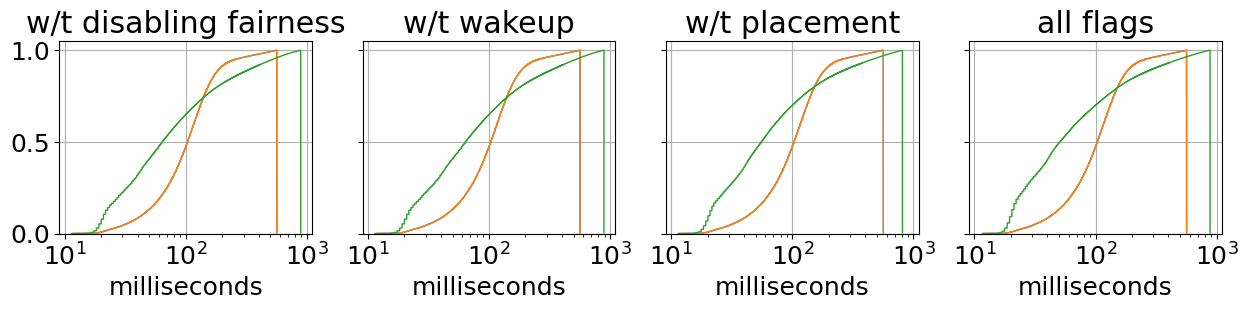

In [47]:

def visualise_latency_cdf(results_cfs, results_llf, fig, ax,workload,func_count):
    dfs = [df for df, _, _, _, _ in results_cfs.values()]
    dfs_llf = [df for df, _, _, _, _ in results_llf.values()]


    dfs = [pd.Series(df.to_numpy().flatten()) for df in dfs]
    dfs_llf = [pd.Series(df.to_numpy().flatten()) for df in dfs_llf]


    dfb = dfs[0]

    for index, count in enumerate(list(results_cfs.keys())):

#         print(index, count)
        
        if (count == func_count):

            quantile = 0.95

            dfb[dfb<dfb.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                                 histtype='step',
                                                  label=f'{12}-funcs-CFS',ax=ax)

            df = dfs[index]
            df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                              histtype='step',
                                              label=f'{count}-funcs-CFS',ax=ax)

            df = dfs_llf[index]
            df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                              histtype='step',
                                              label=f'{count}-funcs-CFS-LLF',ax=ax)     


            ax.set_title(workload,)
            ax.set_xlabel("milliseconds")

fig, ax = plt.subplots(1,4,figsize=(15,2.5),sharey=True,sharex=True)            

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[0],'resctl',1)
# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[1],'resctl',12)
# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_relaxed,fig,ax[1],'resctl',204)
# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[0],'resctlx0.5',56, )
# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[1],'resctlx1',112)

visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf_woutwakeup,fig,ax[0],'w/t disabling fairness',204)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf_woutwakeup,fig,ax[1],'w/t wakeup',204)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf_minimal,fig,ax[2],'w/t placement',204)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[3],'all flags',204)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[3],'resctlx4',448)
# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[4],'resctlx8',896)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')


In [57]:
results_notraceclean_cfs_cpuset = {}
results_notraceclean_llf_cpuset = {}
!git diff ../scripts/
!git diff ../rd-hashd/
!sudo cp ../rd-hashd/func@.service /etc/systemd/system/
!sudo systemctl daemon-reload
!cat /etc/systemd/system/func@.service

diff --git a/scripts/setup_patch_clean_cfs.sh b/scripts/setup_patch_clean_cfs.sh
index a31c532..b2de0a5 100755
--- a/scripts/setup_patch_clean_cfs.sh
+++ b/scripts/setup_patch_clean_cfs.sh
@@ -40,8 +40,8 @@ echo "/sys/fs/cgroup/cpu/*/cpu.shares"
 echo "/sys/fs/cgroup/cpu/*/*/cpu.shares"
 #echo "/sys/fs/cgroup/cpu/*/*/*/cpu.shares"
 #echo "/sys/fs/cgroup/cpu/*/*/*/*/cpu.shares"
-echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/cpu.shares
-echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/*/cpu.shares
+echo '1024' | sudo tee -a /sys/fs/cgroup/*/cpu.weight
+echo '1024' | sudo tee -a /sys/fs/cgroup/*/*/cpu.weight
 #echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/*/*/cpu.shares
 #echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/*/*/*/cpu.shares
 echo "--------"
diff --git a/scripts/setup_patch_clean_systemd.sh b/scripts/setup_patch_clean_systemd.sh
index e1aa179..4fb516d 100755
--- a/scripts/setup_patch_clean_systemd.sh
+++ b/scripts/setup_patch_clean_systemd.sh
@@ -35,8 +35,8 @@ echo "/sys/fs/cgro

In [58]:

print(density_range)

for x in density_range: 
    results_notraceclean_cfs_cpuset[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


print(density_range)

for x in density_range: 
    results_notraceclean_llf_cpuset[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)  

[204]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

204 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-99

/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 16:13:46 helios.cl.cam.ac.uk rd-hashd[108178]: [INFO] p50:184.2 p84:210.7 p90:254.9 p99:256.7 rps:   4.5 con:  1.0
Jul 22 16:13:56 helios.cl.cam.ac.uk rd-hashd[108178]: [INFO] p50:165.0 p84:208.9 p90:268.6 p99:268.6 rps:   4.5 con:  1.0
Jul 22 16:14:06 helios.cl.cam.ac.uk rd-hashd[108178]: [INFO] p50:179.7 p84:223.3 p90:252.1 p99:253.0 rps:   4.4 con:  1.0
Jul 22 16:14:17 helios.cl.cam.ac.uk rd-hashd[108178]: [INFO] p50:189.1 p84:237.0 p90:277.0 p99:277.0 rps:   4.1 con:  1.0
Jul 22 16:14:27 helios.cl.cam.ac.uk rd-hashd[108178]: [INFO] p50:201.3 p84:239.6 p90:272.6 p99:272.6 rps:   4.5 con:  1.0
Jul 22 16:14:37 helios.cl.cam.ac.uk rd-hashd[108178]: [INFO] p50:204.3 p84:261.7 p90:310.4 p99:311.0 rps:   3.9 con:  1.0
Jul 22 16:14:43 helios.cl.cam.ac.uk systemd[1]: Stopping Function stress 0...
Jul 22 16:14:43 helios.cl.cam.ac.

...

tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 16:14:43 helios.cl.cam.ac.uk systemd[1]: func@0.service: Consumed 12.035s CPU time.
Jul 22 16:15:03 helios.cl.cam.ac.uk systemd[1]: Started Function stress 0.
Jul 22 16:15:03 helios.cl.cam.ac.uk rd-hashd[115021]: [INFO] Dropping page cache for testfiles
Jul 22 16:15:03 helios.cl.cam.ac.uk rd-hashd[115021]: [INFO] Starting hasher (maxcon=65536 lat=100.0ms rps=65536 file=0.06G anon=0.19G)
Jul 22 16:15:03 helios.cl.cam.ac.uk rd-hashd[115021]: [INFO] Setting up hash logging at results/logs-0 (31.38G @ 1.05Mbps pad 1.08k)
Jul 22 16:15:03 helios.cl.cam.ac.uk rd-hashd[115021]: No trace provided, executing default code path...
Jul 22 16:15:14 helios.cl.cam.ac.uk rd-hashd[115021]: [INFO] p50:194.1 p84:328.5 p90:349.4 p99:384.6 rps:  17.2 con:  1.7
Jul 22 16:15:27 helios.cl.cam.ac.uk rd-hashd[115021]: [INFO] p50:154.8 p84:204.4 p90:22

nr_switches    857037
dtype: int64

yield                           280181
schedule                       1250568
idle                             21464
try_to_wake_up                  471894
try_to_wake_up local            445342
tasks_running            1407490230254
tasks_waiting           32378765115105
timeslices                      835842
dtype: int64

In [62]:
results_notraceclean_cfs_cpuset2nodes = {}
results_notraceclean_llf_cpuset2nodes = {}
!git diff ../scripts/
!git diff ../rd-hashd/
!sudo cp ../rd-hashd/func@.service /etc/systemd/system/
!sudo systemctl daemon-reload
!cat /etc/systemd/system/func@.service

diff --git a/scripts/setup_patch_clean_cfs.sh b/scripts/setup_patch_clean_cfs.sh
index a31c532..b2de0a5 100755
--- a/scripts/setup_patch_clean_cfs.sh
+++ b/scripts/setup_patch_clean_cfs.sh
@@ -40,8 +40,8 @@ echo "/sys/fs/cgroup/cpu/*/cpu.shares"
 echo "/sys/fs/cgroup/cpu/*/*/cpu.shares"
 #echo "/sys/fs/cgroup/cpu/*/*/*/cpu.shares"
 #echo "/sys/fs/cgroup/cpu/*/*/*/*/cpu.shares"
-echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/cpu.shares
-echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/*/cpu.shares
+echo '1024' | sudo tee -a /sys/fs/cgroup/*/cpu.weight
+echo '1024' | sudo tee -a /sys/fs/cgroup/*/*/cpu.weight
 #echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/*/*/cpu.shares
 #echo '1024' | sudo tee -a /sys/fs/cgroup/cpu/*/*/*/*/cpu.shares
 echo "--------"
diff --git a/scripts/setup_patch_clean_systemd.sh b/scripts/setup_patch_clean_systemd.sh
index e1aa179..4fb516d 100755
--- a/scripts/setup_patch_clean_systemd.sh
+++ b/scripts/setup_patch_clean_systemd.sh
@@ -35,8 +35,8 @@ echo "/sys/fs/cgro

In [63]:

print(density_range)

for x in density_range: 
    results_notraceclean_cfs_cpuset2nodes[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


print(density_range)

for x in density_range: 
    results_notraceclean_llf_cpuset2nodes[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)  

[204]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

204 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-99

/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 16:42:57 helios.cl.cam.ac.uk rd-hashd[123010]: [INFO] p50:102.6 p84:136.0 p90:136.3 p99:162.4 rps:   8.1 con:  1.8
Jul 22 16:43:08 helios.cl.cam.ac.uk rd-hashd[123010]: [INFO] p50: 96.8 p84:126.3 p90:131.9 p99:152.2 rps:   8.3 con:  1.9
Jul 22 16:43:18 helios.cl.cam.ac.uk rd-hashd[123010]: [INFO] p50:113.3 p84:141.3 p90:143.0 p99:176.6 rps:   8.1 con:  2.0
Jul 22 16:43:28 helios.cl.cam.ac.uk rd-hashd[123010]: [INFO] p50:106.2 p84:146.8 p90:148.7 p99:175.8 rps:   8.0 con:  1.9
Jul 22 16:43:38 helios.cl.cam.ac.uk rd-hashd[123010]: [INFO] p50: 96.9 p84:126.8 p90:126.8 p99:141.3 rps:   8.0 con:  2.0
Jul 22 16:43:48 helios.cl.cam.ac.uk rd-hashd[123010]: [INFO] p50:111.2 p84:156.4 p90:156.4 p99:199.6 rps:   7.9 con:  1.7
Jul 22 16:43:55 helios.cl.cam.ac.uk systemd[1]: Stopping Function stress 0...
Jul 22 16:43:55 helios.cl.cam.ac.

...

tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90


/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[cpu] = cpu_entry[2:]
/tmp/ipykernel_2899/4059827930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d

○ func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 22 16:44:19 helios.cl.cam.ac.uk rd-hashd[131827]: [INFO] Starting hasher (maxcon=65536 lat=100.0ms rps=65536 file=0.06G anon=0.19G)
Jul 22 16:44:19 helios.cl.cam.ac.uk rd-hashd[131827]: [INFO] Setting up hash logging at results/logs-0 (31.38G @ 1.05Mbps pad 1.08k)
Jul 22 16:44:19 helios.cl.cam.ac.uk rd-hashd[131827]: No trace provided, executing default code path...
Jul 22 16:44:31 helios.cl.cam.ac.uk rd-hashd[131827]: [INFO] p50:297.8 p84:467.3 p90:510.1 p99:648.2 rps:  38.3 con:  4.1
Jul 22 16:44:41 helios.cl.cam.ac.uk rd-hashd[131827]: [INFO] p50:136.4 p84:189.8 p90:198.8 p99:222.5 rps:   8.9 con:  1.7
Jul 22 16:44:52 helios.cl.cam.ac.uk rd-hashd[131827]: [INFO] p50: 90.6 p84:121.3 p90:131.2 p99:183.1 rps:   8.0 con:  1.8
Jul 22 16:46:32 helios.cl.cam.ac.uk systemd[1]: Stopping Function stress 0...
Jul 22 16:46:32 helios.cl.

nr_switches    1585195
dtype: int64

yield                           420678
schedule                       2224710
idle                             23279
try_to_wake_up                  841443
try_to_wake_up local            768423
tasks_running            2811493321418
tasks_waiting           46713492736391
timeslices                     1562727
dtype: int64

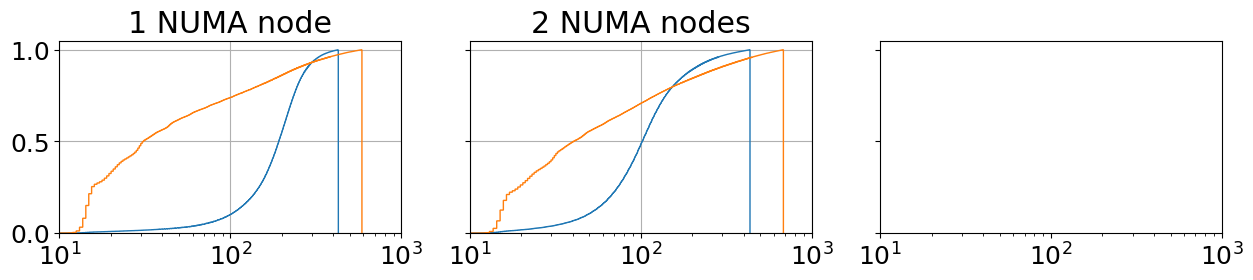

In [70]:


# dfb = dfs[0]

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

quantile = 0.95
df,_,_,_,_ = results_notraceclean_cfs_cpuset[204]
df = pd.Series(df.to_numpy().flatten()) 
df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                  histtype='step',
                                  label=f'{896}-funcs-CFS-LLF1000',ax=ax[0])

quantile = 0.95
df,_,_,_,_ = results_notraceclean_llf_cpuset[204]
df = pd.Series(df.to_numpy().flatten()) 

df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                  histtype='step',
                                  label=f'{896}-funcs-CFS-LLF3000',ax=ax[0])    



quantile = 0.95
df,_,_,_,_ = results_notraceclean_cfs_cpuset2nodes[204]
df = pd.Series(df.to_numpy().flatten()) 
df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                  histtype='step',
                                  label=f'{896}-funcs-CFS-LLF1000',ax=ax[1])

quantile = 0.95
df,_,_,_,_ = results_notraceclean_llf_cpuset2nodes[204]
df = pd.Series(df.to_numpy().flatten()) 

df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                  histtype='step',
                                  label=f'{896}-funcs-CFS-LLF3000',ax=ax[1])    
ax[0].set_title('1 NUMA node')
ax[1].set_title('2 NUMA nodes')



for x in range(2):
    ax[x].set_xscale('log')
    ax[x].set_xlim(10,1000)

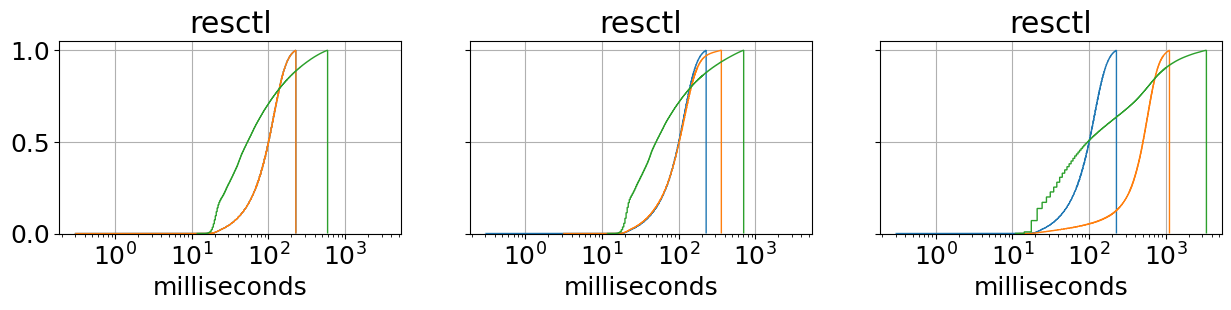

In [40]:

def visualise_latency_cdf(results_cfs, results_llf, fig, ax,workload,func_count):
    dfs = [df for df, _, _, _, _ in results_cfs.values()]
    dfs_llf = [df for df, _, _, _, _ in results_llf.values()]


    dfs = [pd.Series(df.to_numpy().flatten()) for df in dfs]
    dfs_llf = [pd.Series(df.to_numpy().flatten()) for df in dfs_llf]


    dfb = dfs[0]

    for index, count in enumerate(list(results_cfs.keys())):

#         print(index, count)
        
        if (count == func_count):

            quantile = 0.95

            dfb[dfb<dfb.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                                 histtype='step',
                                                  label=f'{12}-funcs-CFS',ax=ax)

            df = dfs[index]
            df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                              histtype='step',
                                              label=f'{count}-funcs-CFS',ax=ax)

            df = dfs_llf[index]
            df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                              histtype='step',
                                              label=f'{count}-funcs-CFS-LLF',ax=ax)     


            ax.set_title(workload,)
            ax.set_xlabel("milliseconds")

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[0],'resctl',1)
# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[1],'resctl',12)
# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_relaxed,fig,ax[1],'resctl',204)

visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[0],'resctl',56)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[1],'resctl',112)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',204)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xscale('log')

In [21]:
results_notraceclean_relaxed = {}


In [23]:
!git diff ./../scripts/

diff --git a/scripts/setup_patch_clean_systemd.sh b/scripts/setup_patch_clean_systemd.sh
index b46e3e3..4c16284 100755
--- a/scripts/setup_patch_clean_systemd.sh
+++ b/scripts/setup_patch_clean_systemd.sh
@@ -15,9 +15,9 @@ echo "-----"
 # # echo "#sched_entity_before_policy == 4 entity_before_relaxed_fairness(a,b)"
 # # echo "#sched_entity_before_policy == 40  entity_before_unfair(a,b) //this destroys performance" 
 # # echo "#sched_entity_before_policy == 20  entity_before_se_load_avg_most(a,b) //this destroys performance"
-sudo sysctl kernel.sched_entity_before_policy=100
-sudo sysctl kernel.sched_check_preempt_wakeup_latency_awareness=100
-sudo sysctl kernel.sched_cpu_has_higher_load_task=100
+sudo sysctl kernel.sched_entity_before_policy=0
+sudo sysctl kernel.sched_check_preempt_wakeup_latency_awareness=0
+sudo sysctl kernel.sched_cpu_has_higher_load_task=0
 echo "-----"
 
 # sudo sysctl kernel.sched_tg_load_avg_sticky=0


In [24]:
density_range = [204]

In [25]:

print(density_range)

for x in density_range: 
    results_notraceclean_relaxed[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)                                                   

[204]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/kubepods.slice/kubepods-burstable.slice/*/cpu.idle
0
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/*/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/*/*/cpu.shares
1024
1024
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
0
-----

204 functions
['

tick 0
tick 10
tick 20
tick 30
tick 40
tick 50
tick 60
tick 70
tick 80
tick 90
● func@0.service - Function stress 0
     Loaded: loaded (/etc/systemd/system/func@.service; disabled; vendor preset: enabled)
     Active: inactive (dead)

Jul 17 18:15:03 caelum-406 rd-hashd[4157950]: [INFO] p50:407.4 p84:434.9 p90:436.5 p99:436.5 rps:   2.4 con:  1.0
Jul 17 18:15:14 caelum-406 rd-hashd[4157950]: [INFO] p50:327.5 p84:371.7 p90:403.6 p99:407.6 rps:   3.3 con:  1.0
Jul 17 18:15:24 caelum-406 rd-hashd[4157950]: [INFO] p50:478.5 p84:540.7 p90:540.7 p99:540.7 rps:   1.8 con:  1.0
Jul 17 18:15:35 caelum-406 rd-hashd[4157950]: [INFO] p50:395.3 p84:444.3 p90:449.4 p99:449.4 rps:   2.3 con:  1.0
Jul 17 18:15:45 caelum-406 rd-hashd[4157950]: [INFO] p50:425.8 p84:464.7 p90:464.7 p99:464.7 rps:   2.1 con:  1.0
Jul 17 18:15:55 caelum-406 rd-hashd[4157950]: [INFO] p50:361.0 p84:421.5 p90:423.8 p99:423.8 rps:   2.7 con:  1.0
Jul 17 18:16:05 caelum-406 rd-hashd[4157950]: [INFO] p50:635.1 p84:672.8 p90:672

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/kubepods.slice/kubepods-burstable.slice/*/cpu.idle
0
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/*/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/*/*/cpu.shares
1024
1024
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
0
-----

duration 100.300195455

nr_switches    1118798
dtype: int64

yield                           485484
schedule                       1313862
idle                                 0
try_to_wake_up                  450226
try_to_wake_up local            435611
tasks_running            1203532351749
tasks_waiting           24512037722981
timeslices                     1118812
dtype: int64

In [34]:
visualise_latency_bars(results_notraceclean_cfs, results_notraceclean_llf)
# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf)
# visualise_schedstat(results_notraceclean_cfs, results_notraceclean_llf)

NameError: name 'visualise_latency_bars' is not defined

# Experiments (ftrace)

In [696]:
!ls /local/scratch/sosp25/results*

/local/scratch/sosp25/results_azure2021clean_cfs
/local/scratch/sosp25/results_azure2021clean_llf
/local/scratch/sosp25/results_azure2021ftrace_cfs
/local/scratch/sosp25/results_azure2021ftrace_llf
/local/scratch/sosp25/results_notraceclean_cfs
/local/scratch/sosp25/results_notraceclean_llf
/local/scratch/sosp25/results_notraceftrace_cfs
/local/scratch/sosp25/results_randomclean_cfs
/local/scratch/sosp25/results_randomclean_llf


In [697]:
!ls /local/scratch/results*

/local/scratch/results_azure2021ftrace_cfs
/local/scratch/results_azure2021ftrace_llf
/local/scratch/results_constantloadftrace_cfs
/local/scratch/results_constantloadftrace_llf
/local/scratch/results_dynamicloadftrace_cfs
/local/scratch/results_dynamicloadftrace_llf

/local/scratch/results:
overcommitment-90  overcommitment-95  overprovisioning


In [448]:
import pickle

file_azure2021ftrace_cfs = open('/local/scratch/sosp25/results_azure2021ftrace_cfs', 'wb')
pickle.dump(results_azure2021ftrace_cfs, file_azure2021ftrace_cfs)

file_azure2021ftrace_llf = open('/local/scratch/results_azure2021ftrace_llf', 'wb')
pickle.dump(results_azure2021ftrace_llf, file_azure2021ftrace_llf)   

In [141]:
file_constantloadftrace_cfs = open('/local/scratch/results_constantloadftrace_cfs', 'wb')
pickle.dump(results_constantloadftrace_cfs, file_constantloadftrace_cfs)

file_constantloadftrace_llf = open('/local/scratch/results_constantloadftrace_llf', 'wb')
pickle.dump(results_constantloadftrace_llf, file_constantloadftrace_llf)   

In [142]:
file_dynamicloadftrace_cfs = open('/local/scratch/sospresults_dynamicloadftrace_cfs', 'wb')
pickle.dump(results_dynamicloadftrace_cfs, file_dynamicloadftrace_cfs)

file_dynamicloadftrace_llf = open('/local/scratch/results_dynamicloadftrace_llf', 'wb')
pickle.dump(results_dynamicloadftrace_llf, file_dynamicloadftrace_llf)   

In [97]:
import pickle


file_cfs = open('/local/scratch/sosp24results_azure2021ftrace_cfs', 'rb')
results_azure2021ftrace_cfs = pickle.load(file_cfs)

file_llf = open('/local/scratch/results_azure2021ftrace_llf', 'rb')
results_azure2021ftrace_llf = pickle.load(file_llf)

# close the file
# file.close()

In [97]:
density_range = [12]

In [111]:
density_range = [x for x in range(12, 12*15, 12)]
density_range

[12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 132, 144, 156, 168]

In [137]:
density_range = [x for x in range(12, 12*20, 12*2)]
density_range

[12, 36, 60, 84, 108, 132, 156, 180, 204, 228]

In [191]:
density_range

[12,
 24,
 36,
 48,
 60,
 72,
 84,
 96,
 108,
 120,
 132,
 144,
 156,
 168,
 180,
 192,
 204,
 216,
 228]

In [ ]:
print(density_range)

results_randomftrace_cfs = {}

for x in density_range: 
    results_randomftrace_cfs[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='random',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=True)
    reboot_and_wait_until_online()
    
print(density_range)

results_randomftrace_llf = {}

for x in density_range: 
    results_randomftrace_llf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='random',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=True)
    reboot_and_wait_until_online()

In [894]:
results_notraceftrace_cfs = reorder_dict_keys(results_notraceftrace_cfs)
results_azure2021ftrace_cfs = reorder_dict_keys(results_azure2021ftrace_cfs)
results_azure2021ftrace_llf = reorder_dict_keys(results_azure2021ftrace_llf)
